In [21]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
base_dirs = {
    "genetics_and_image": "/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/genetics_and_image",
    "only_genetics": "/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/only_genetics",
    "only_image": "/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/only_image"
}


sub_folders = {
    "all_batch": ["cancertypebatching_exp_0_phase2_10", "cancertypebatching_exp_1_phase2_0"],
    "ct_batch": ["cancertypebatching_exp_0_warmup_0", "cancertypebatching_exp_1_warmup_10"]
}

csv_files = ["global_test_cindices.csv", "global_test_risk_scores.csv"]


all_csv_data = {}

for mode, base_dir in base_dirs.items():
    all_csv_data[mode] = {}
    for batch_type, exp_dirs in sub_folders.items():
        all_csv_data[mode][batch_type] = {}
        for exp_dir in exp_dirs:
            exp_path = os.path.join(base_dir, batch_type, exp_dir)
            all_csv_data[mode][batch_type][exp_dir] = {}
            for csv_file in csv_files:
                file_path = os.path.join(exp_path, csv_file)
                try:
                    all_csv_data[mode][batch_type][exp_dir][csv_file] = pd.read_csv(file_path)
                except FileNotFoundError:
                    print(f"Missing: {file_path}")
                    all_csv_data[mode][batch_type][exp_dir][csv_file] = None

In [22]:
base_dir = "/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/genetics_and_image"
batch_type = "all_batch"
exp_dir = "cancertypebatching_exp_0_phase2_10"
csv_file = "global_test_cindices.csv"

file_path = os.path.join(base_dir, batch_type, exp_dir, csv_file)

# Load the CSV
cindex_df = pd.read_csv(file_path)
print(cindex_df)

    cancer_type   c_index
0             8  0.501033
1             2  0.532815
2            10  0.486309
3            12  0.585014
4            11  0.554278
5            17  0.634139
6            15  0.508911
7            13  0.635819
8            20  0.547747
9            19  0.516460
10            6  0.571491
11            7  0.567961
12            3  0.504971
13            4  0.621094
14            1  0.581763
15            0  0.707595
16           21  0.596875
17           18  0.584267
18           35  0.501114
19           36  0.512273
20           14  0.555773
21           26  0.550651
22           28  0.621091
23           27  0.497244
24           23  0.539118
25           33  0.636175
26           25  0.505593
27           32  0.523862
28           30  0.551342
29           31  0.658768
30           24  0.582915
31           29  0.570370
32           34  0.609166


Kaplan Meier Plots

In [23]:
base_dir = "/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/genetics_and_image"
batch_type = "all_batch"
exp_dir = "cancertypebatching_exp_0_phase2_10"
csv_file = "global_test_risk_scores.csv"

file_path = os.path.join(base_dir, batch_type, exp_dir, csv_file)

# Load the CSV
risk_df = pd.read_csv(file_path)
print(risk_df)

           Case ID  OS.time   OS       risk  normalized_risk  cancer_type  \
0     TCGA-L5-A43C     96.0  0.0   7.782428        -0.003303            8   
1     TCGA-L5-A4OO    101.0  0.0   7.992639         0.198492            8   
2     TCGA-R6-A6L4    496.0  1.0   6.285508        -1.440291            8   
3     TCGA-E2-A154    591.0  0.0   7.760184        -0.024656            2   
4     TCGA-EW-A1OV    789.0  0.0   7.998481         0.204101            2   
...            ...      ...  ...        ...              ...          ...   
9445  TCGA-EY-A549    605.0  0.0  20.607252         0.258104           34   
9446  TCGA-AP-A1DH   2180.0  0.0  22.334840         1.058286           34   
9447  TCGA-AP-A052    669.0  1.0  23.275385         1.493926           34   
9448  TCGA-A5-A0GV   1643.0  0.0  20.695097         0.298792           34   
9449  TCGA-EY-A3L3    832.0  0.0  20.373226         0.149708           34   

      fold  
0        1  
1        1  
2        1  
3        1  
4        1

In [36]:
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [37]:
risk0_df = risk_df[risk_df["cancer_type"] == 0]
risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25

/tmp/ipykernel_19247/40765996.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25


In [38]:
median_risk = risk0_df['normalized_risk'].median()
high_risk = risk0_df[risk0_df['normalized_risk'] >= median_risk]
low_risk = risk0_df[risk0_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()


In [39]:
kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")



<lifelines.KaplanMeierFitter:"High Risk", fitted with 41 total observations, 23 right-censored observations>

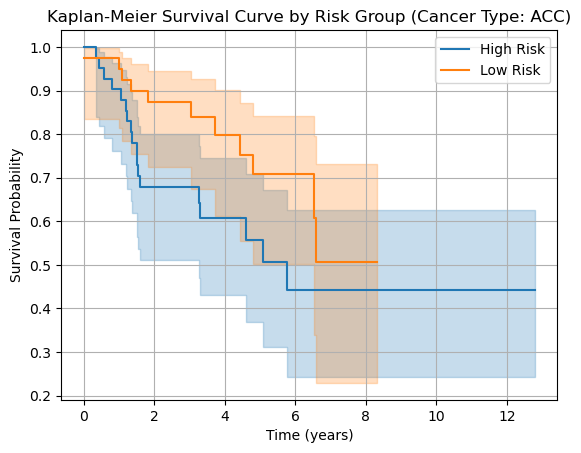

In [40]:
ax = kmf_high.plot()
kmf_low.plot(ax=ax)
plt.title('Kaplan-Meier Survival Curve by Risk Group (Cancer Type: ACC)')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.show()


In [48]:
risk7_df = risk_df[risk_df["cancer_type"] == 17]
risk7_df['OS.time'] = risk7_df['OS.time'] / 365.25

/tmp/ipykernel_19247/229297027.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk7_df['OS.time'] = risk7_df['OS.time'] / 365.25


In [49]:
median_risk = risk7_df['normalized_risk'].median()
high_risk = risk7_df[risk7_df['normalized_risk'] >= median_risk]
low_risk = risk7_df[risk7_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()


In [50]:
kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")



<lifelines.KaplanMeierFitter:"High Risk", fitted with 238 total observations, 159 right-censored observations>

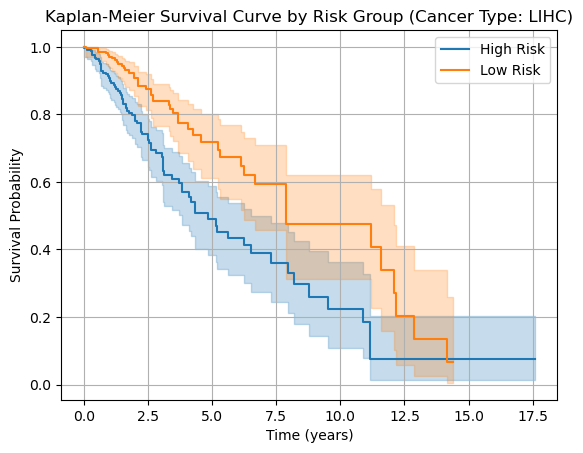

In [52]:
ax = kmf_high.plot()
kmf_low.plot(ax=ax)
plt.title('Kaplan-Meier Survival Curve by Risk Group (Cancer Type: LIHC)')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.show()


Messed up kaplans

/tmp/ipykernel_19247/887510339.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25


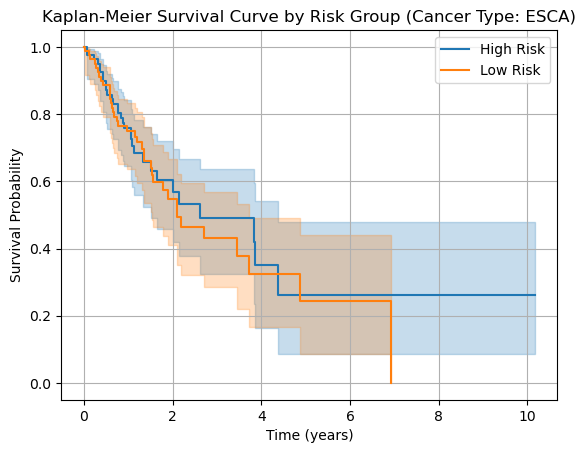

In [54]:
risk0_df = risk_df[risk_df["cancer_type"] == 8]
risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25
median_risk = risk0_df['normalized_risk'].median()
high_risk = risk0_df[risk0_df['normalized_risk'] >= median_risk]
low_risk = risk0_df[risk0_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")

ax = kmf_high.plot()
kmf_low.plot(ax=ax)
plt.title('Kaplan-Meier Survival Curve by Risk Group (Cancer Type: ESCA)')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.show()


/tmp/ipykernel_19247/3090232519.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25


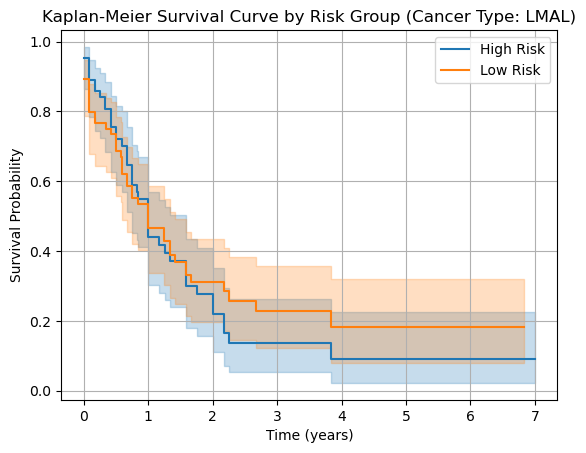

In [57]:
risk0_df = risk_df[risk_df["cancer_type"] == 15]
risk0_df['OS.time'] = risk0_df['OS.time'] / 365.25
median_risk = risk0_df['normalized_risk'].median()
high_risk = risk0_df[risk0_df['normalized_risk'] >= median_risk]
low_risk = risk0_df[risk0_df['normalized_risk'] < median_risk]

# %%
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_low.fit(low_risk['OS.time'], event_observed=low_risk['OS'], label="Low Risk")
kmf_high.fit(high_risk['OS.time'], event_observed=high_risk['OS'], label="High Risk")

ax = kmf_high.plot()
kmf_low.plot(ax=ax)
plt.title('Kaplan-Meier Survival Curve by Risk Group (Cancer Type: LMAL)')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.grid(True)

plt.show()
